# Taller 6: Morfología matemática

### Sebastián Palma

### David Tobón Molina

In [222]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 1. Operadores de dilatación y erosión

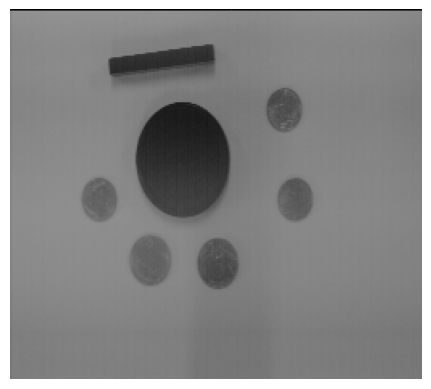

In [223]:
morpho_imagen = cv2.imread('images/MORPHO.png', cv2.IMREAD_GRAYSCALE)

plt.imshow(morpho_imagen, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 1.3 Haga una umbralización de esta imagen, para obtener objetos negros sobre fondo blanco (umbral alrededor de 115).

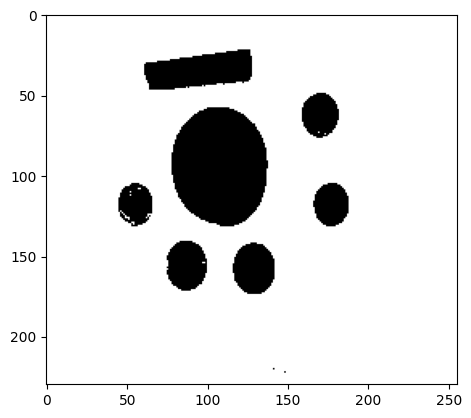

In [224]:
thres_value, morpho_umbralizacion = cv2.threshold(morpho_imagen, 114, 255, cv2.THRESH_BINARY)

plt.imshow(morpho_umbralizacion, cmap='gray', vmin=0, vmax=255)
plt.show()

### 1.4 Sobre la imagen binaria efectúe una dilatación con un elemento estructurante o máscara cuadrada de 29x29. ¿Qué obtiene como resultado?

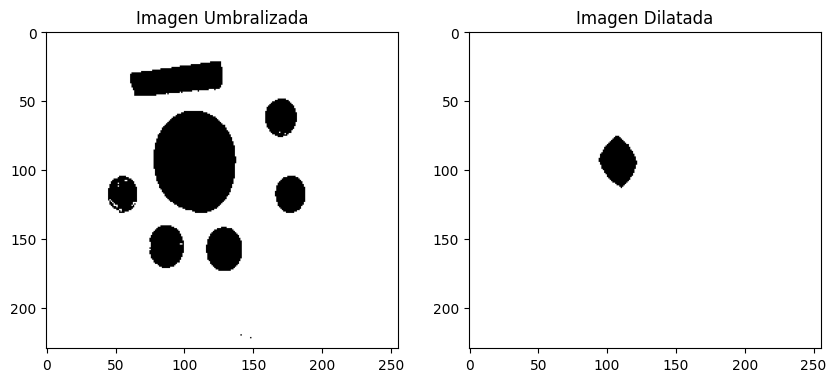

In [225]:
from skimage.morphology import dilation

elemento_estructural = np.ones((29, 29), np.uint8)
morpho_dilatada = dilation(morpho_umbralizacion, footprint = elemento_estructural)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Imagen Umbralizada")
plt.imshow(morpho_umbralizacion, cmap="gray", vmin=0, vmax=255)
plt.subplot(1, 2, 2)
plt.title("Imagen Dilatada")
plt.imshow(morpho_dilatada, cmap="gray", vmin=0, vmax=255)
plt.show()

Al aplicar la dilatación con una máscara cuadrada de 29x29 sobre la imagen umbralizada, el fondo blanco se expande y los objetos negros se reducen considerablemente, por lo que desaparecen los más pequeños y solo permanece el objeto de mayor tamaño aunque en menor proporcion.

### 1.5 Sobre la imagen resultante, haga una erosión con la misma máscara. ¿Cómo es el objeto obtenido con respecto al original?

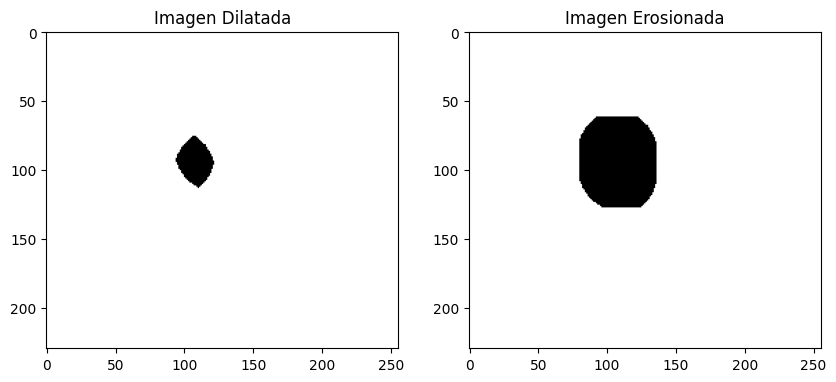

In [226]:
from skimage.morphology import erosion

morpho_erosionada = erosion(morpho_dilatada, footprint=elemento_estructural)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Imagen Dilatada")
plt.imshow(morpho_dilatada, cmap="gray", vmin=0, vmax=255)
plt.subplot(1, 2, 2)
plt.title("Imagen Erosionada")
plt.imshow(morpho_erosionada, cmap="gray", vmin=0, vmax=255)
plt.show()

Al erosionar la imagen dilatada con la misma máscara de 29x29, el objeto negro que permanecía vuelve a crecer y recupera una forma similar a la del objeto original más grande, aunque no queda muy similar. En comparación con el original, se observa más regular, más limpio y sin los objetos pequeños que fueron eliminados en el paso anterior.

### 1.6 Sobre la imagen resultado del punto anterior, haga una erosión con una máscara en cruz, de tamaño 11x11. Las máscaras en cruz deben crearse generando una matriz de nxn (tamaño deseado) y colocando 1’ s en la cruz. Los demás elementos se deben dejar vacíos (SIN CEROS).

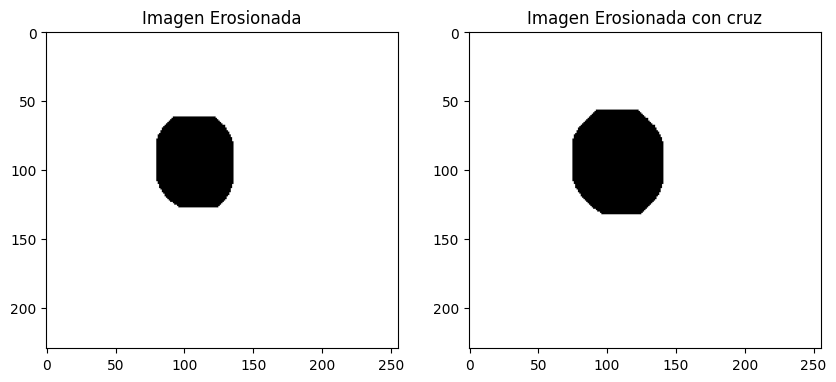

In [227]:
elemento_estructural_1 = np.zeros((11, 11), np.uint8)
elemento_estructural_1[5, :] = 1
elemento_estructural_1[:, 5] = 1

morpho_erosionada_2 = erosion(morpho_erosionada, footprint=elemento_estructural_1)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Imagen Erosionada")
plt.imshow(morpho_erosionada, cmap="gray", vmin=0, vmax=255)
plt.subplot(1, 2, 2)
plt.title("Imagen Erosionada con cruz")
plt.imshow(morpho_erosionada_2, cmap="gray", vmin=0, vmax=255)
plt.show()

### 1.7 Calcule el máximo entre esta última imagen y la imagen original umbralizada. ¿Cómo es el resultado obtenido?

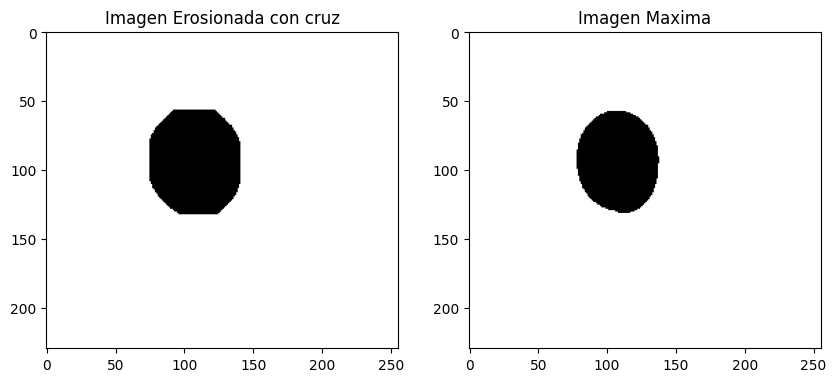

In [228]:
morpho_maximo = np.maximum(morpho_umbralizacion, morpho_erosionada_2)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Imagen Erosionada con cruz")
plt.imshow(morpho_erosionada_2, cmap="gray", vmin=0, vmax=255)
plt.subplot(1, 2, 2)
plt.title("Imagen Maxima")
plt.imshow(morpho_maximo, cmap="gray", vmin=0, vmax=255)
plt.show()

Al calcular el máximo entre la imagen erosionada con cruz y la imagen original umbralizada, se obtiene un objeto más parecido al original principal, con una forma más redondeada. El resultado mantiene el objeto más grande y recupera parte de su apariencia original, mientras los objetos pequeños siguen sin aparecer.

### 1.8 Repita las operaciones 1 a 4, trabajando directamente con la imagen original no umbralizada (en niveles de gris).

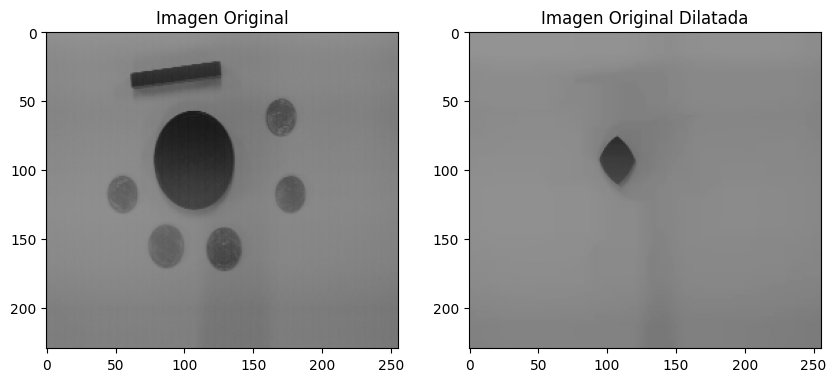

In [229]:
morpho_original_dilata = dilation(morpho_imagen, footprint=elemento_estructural)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Imagen Original")
plt.imshow(morpho_imagen, cmap="gray", vmin=0, vmax=255)
plt.subplot(1, 2, 2)
plt.title("Imagen Original Dilatada")
plt.imshow(morpho_original_dilata, cmap="gray", vmin=0, vmax=255)
plt.show()

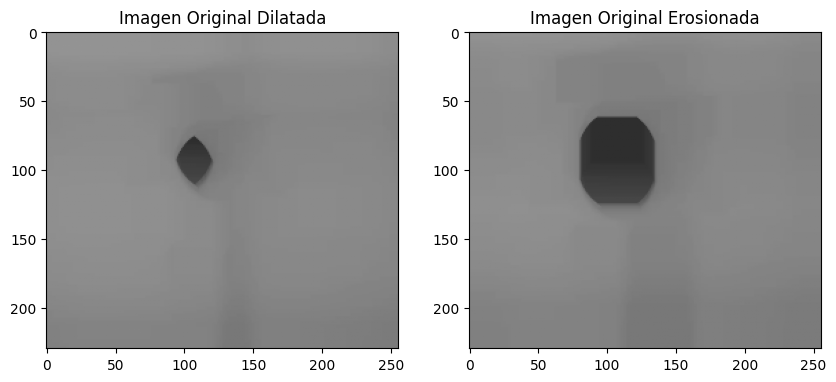

In [230]:
morpho_original_erosionada = erosion(morpho_original_dilata, footprint=elemento_estructural)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Imagen Original Dilatada")
plt.imshow(morpho_original_dilata, cmap="gray", vmin=0, vmax=255)
plt.subplot(1, 2, 2)
plt.title("Imagen Original Erosionada")
plt.imshow(morpho_original_erosionada, cmap="gray", vmin=0, vmax=255)
plt.show()

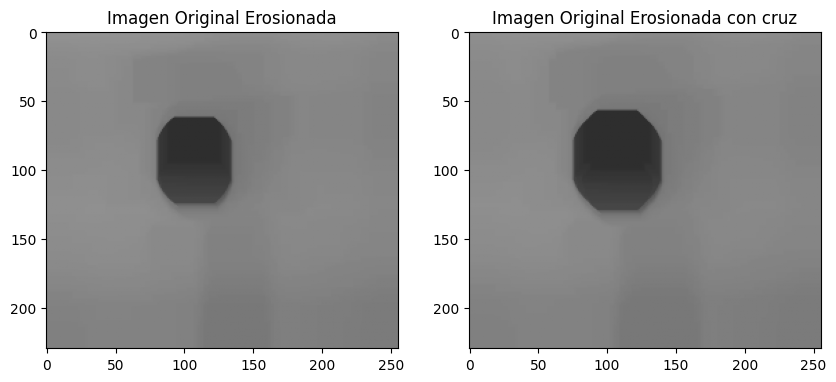

In [231]:
elemento_estructural_1 = np.zeros((11, 11), np.uint8)
elemento_estructural_1[5, :] = 1
elemento_estructural_1[:, 5] = 1

morpho_original_erosionada_2 = erosion(morpho_original_erosionada, footprint=elemento_estructural_1)
1
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Imagen Original Erosionada")
plt.imshow(morpho_original_erosionada, cmap="gray", vmin=0, vmax=255)
plt.subplot(1, 2, 2)
plt.title("Imagen Original Erosionada con cruz")
plt.imshow(morpho_original_erosionada_2, cmap="gray", vmin=0, vmax=255)
plt.show()

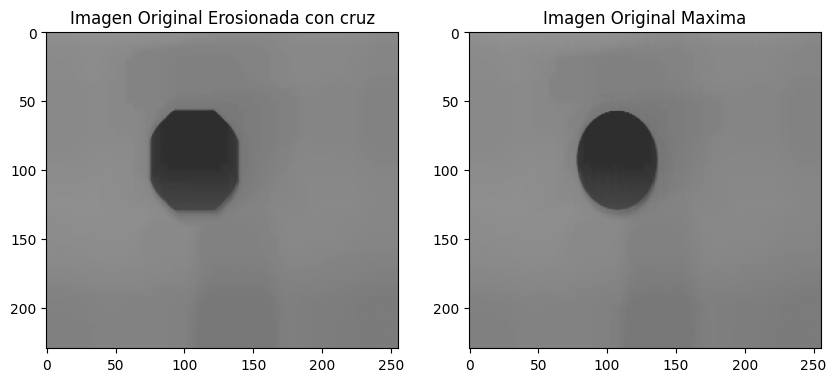

In [232]:
morpho_original_maximo = np.maximum(morpho_imagen, morpho_original_erosionada_2)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Imagen Original Erosionada con cruz")
plt.imshow(morpho_original_erosionada_2, cmap="gray", vmin=0, vmax=255)
plt.subplot(1, 2, 2)
plt.title("Imagen Original Maxima")
plt.imshow(morpho_original_maximo, cmap="gray", vmin=0, vmax=255)
plt.show()

### 1.9 ¿Cómo funcionan las operaciones de erosión y de dilatación en imágenes en niveles de gris?

En imágenes en niveles de gris, la dilatación y la erosión no trabajan únicamente con píxeles blancos y negros, sino con los valores de intensidad que hay dentro de una vecindad definida por el elemento estructurante. La dilatación asigna a cada píxel el valor máximo encontrado en esa vecindad, mientras que la erosión asigna el valor mínimo. Por esta razón, la dilatación tiende a expandir las regiones más claras y a disminuir la presencia de zonas oscuras pequeñas, mientras que la erosión produce el efecto contrario, ya que expande visualmente las zonas más oscuras y reduce las claras. Además, estas operaciones no solo modifican el tamaño aparente de los objetos, sino también sus bordes, el contraste local y la suavidad de las transiciones entre regiones.

### 1.10 ¿Cómo es el resultado obtenido sobre la imagen en niveles de gris, comparado con el resultado sobre la imagen binaria?

Al comparar los resultados obtenidos en la imagen en niveles de gris con los de la imagen binaria, se nota que el procesamiento en grises conserva mucha más información de la imagen original. Mientras que en la imagen binaria cada píxel se reduce a solo dos valores posibles, lo que simplifica mucho la escena y elimina detalles como variaciones internas de intensidad, sombras y transiciones suaves en los bordes. En la imagen en niveles de gris todavía se mantienen esos cambios graduales de tono, por lo que el objeto principal sigue siendo visible y los objetos pequeños pueden atenuarse o desaparecer sin que la imagen pierda por completo su apariencia original. Por eso, el resultado en binario se ve más brusco y más rígido, mientras que en niveles de gris se percibe más natural, más continuo y visualmente más cercano a la imagen inicial.

## 2. Gradiente morfológico

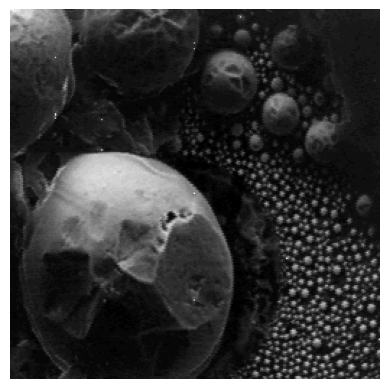

In [233]:
meb_imagen = cv2.imread('images/MEB.png', cv2.IMREAD_GRAYSCALE)

plt.imshow(meb_imagen, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 2.3 Utilizando una máscara cuadrada de 3x3, calcule el gradiente morfológico de esta imagen.

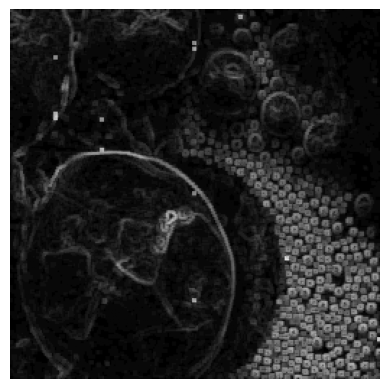

In [234]:
from scipy.ndimage import morphological_gradient

meb_gradiente = morphological_gradient(meb_imagen, size=(3, 3))

plt.imshow(meb_gradiente, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 2.4 Genere la imagen de la norma del gradiente de la imagen meb.png con el operador de Sobel (ver Taller 3). Compare los resultados obtenidos (gradiente morfológico vs. norma del gradiente con Sobel). Puede efectuar una expansión del contraste sobre las dos imágenes obtenidas para visualizar mejor el resultado.

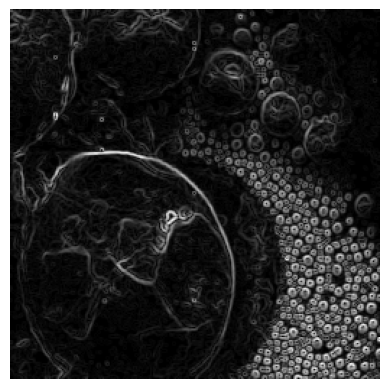

In [235]:
from skimage.filters import sobel

meb_sobel = sobel(meb_imagen)

plt.imshow(meb_sobel, cmap='gray')
plt.axis('off')
plt.show()

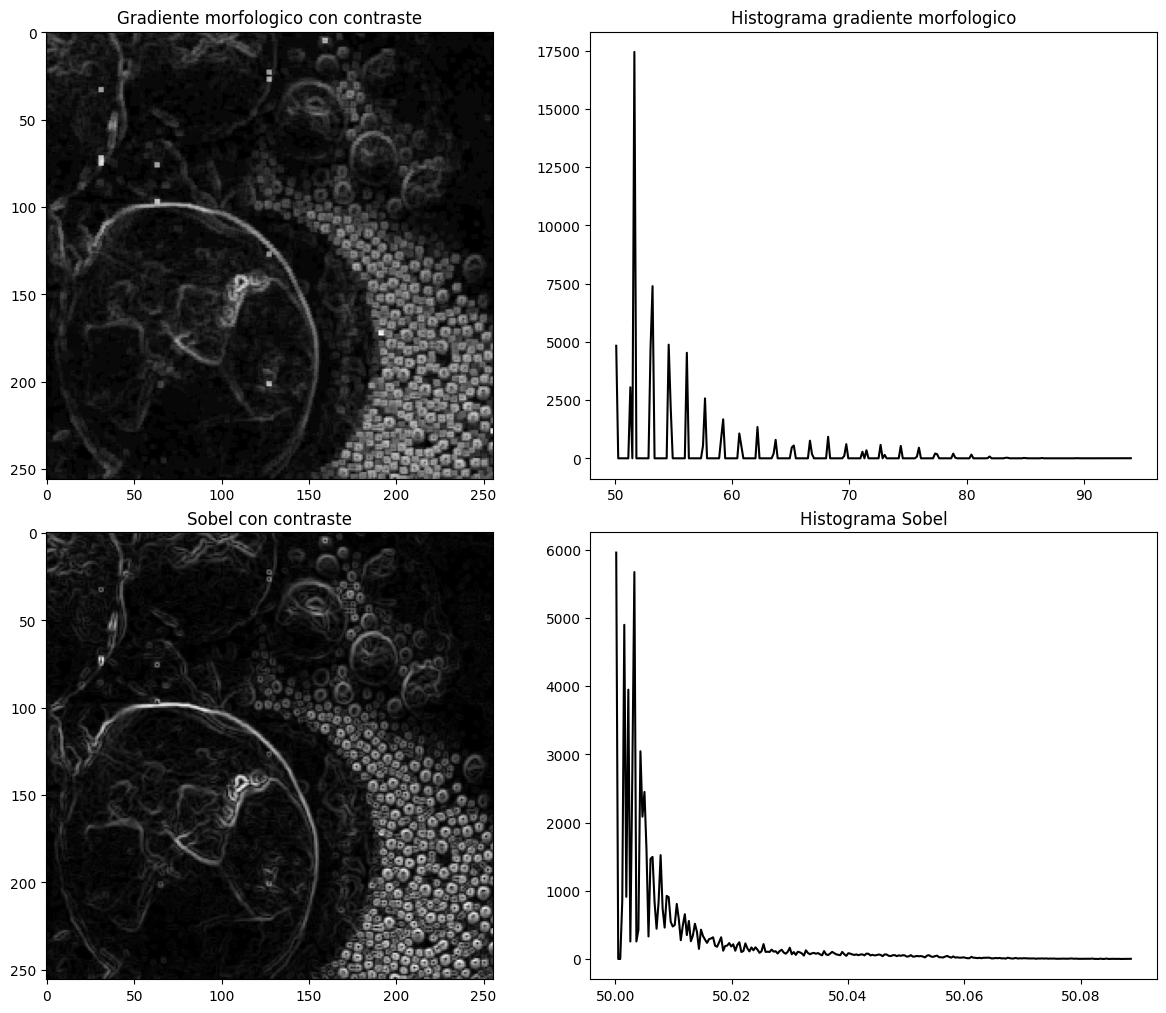

In [236]:
from skimage import exposure

expansion_gradiente = exposure.rescale_intensity(meb_gradiente, in_range=(0,255), out_range=(50, 100))
expansion_sobel = exposure.rescale_intensity(meb_sobel, in_range=(0,255), out_range=(50, 100))
histograma_gradiente = exposure.histogram(expansion_gradiente)
histograma_sobel = exposure.histogram(expansion_sobel)

plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
plt.title("Gradiente morfologico con contraste")
plt.imshow(expansion_gradiente, cmap='gray')
plt.subplot(2, 2, 2)
plt.title("Histograma gradiente morfologico")
plt.plot(histograma_gradiente[1], histograma_gradiente[0], color='black')
plt.tight_layout()
plt.subplot(2, 2, 3)
plt.title("Sobel con contraste")
plt.imshow(expansion_sobel, cmap='gray')
plt.subplot(2, 2, 4)
plt.title("Histograma Sobel")
plt.plot(histograma_sobel[1], histograma_sobel[0], color='black')
plt.subplots_adjust(hspace=0.12)
plt.show()

Al aplicar la expansión de contraste, la comparación entre ambas imágenes se aprecia mucho mejor, puesto que los bordes resaltan con más claridad. Se puede observar cómo el gradiente morfológico muestra contornos más gruesos y marcados, lo que facilita la identificación de los objetos. Por otro lado, el operador de Sobel produce bordes más finos y detallados, por lo que representa mejor las variaciones locales de intensidad.

### 2.5 Repita la operación 3 empleando la misma máscara, pero SIN utilizar el operador de gradiente morfológico (créelo con los operadores de dilatación y de erosión, precedidos por un filtrado mediano). ¿Cómo es el resultado obtenido?

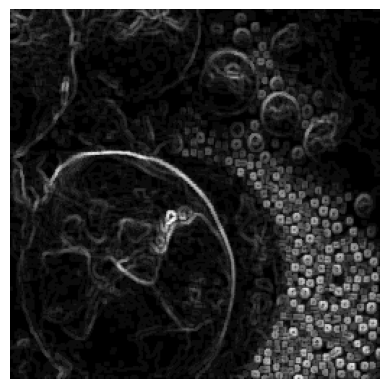

In [237]:
from skimage.filters.rank import median
from skimage.morphology import footprint_rectangle, erosion as morf_erosion

filtro = median(meb_imagen, footprint=footprint_rectangle((3, 3)))
erosionada = morf_erosion(filtro, footprint=footprint_rectangle((3, 3)))
dilatada = dilation(filtro, footprint=footprint_rectangle((3, 3)))
gradiente = dilatada - erosionada

plt.imshow(gradiente, cmap='gray')
plt.axis('off')
plt.show()

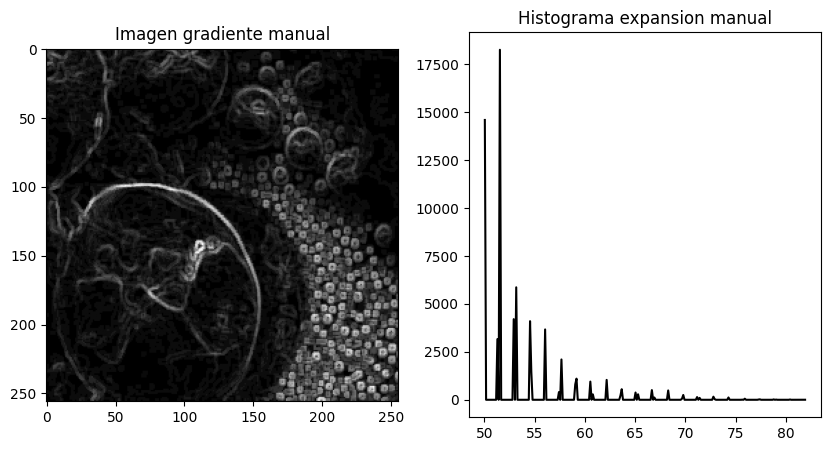

In [238]:
expansion_manual = exposure.rescale_intensity(gradiente, in_range=(0,255), out_range=(50, 100))
histograma_manual = exposure.histogram(expansion_manual)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Imagen gradiente manual")
plt.imshow(expansion_manual, cmap="gray")
plt.subplot(1, 2, 2)
plt.title("Histograma expansion manual")
plt.plot(histograma_manual[1], histograma_manual[0], color='black')
plt.show()

Al construir el gradiente manualmente, aplicando primero un filtro mediano y luego restando la erosión de la dilatación, se obtiene un resultado muy similar al gradiente morfológico calculado directamente, ya que en ambos casos se resaltan los bordes principales de la imagen. Sin embargo, el uso previo del filtro mediano hace que el resultado manual se vea un poco más limpio y estable, porque reduce pequeñas variaciones y ruido antes de aplicar las operaciones morfológicas.

## 3. Operadores de apertura y cierre

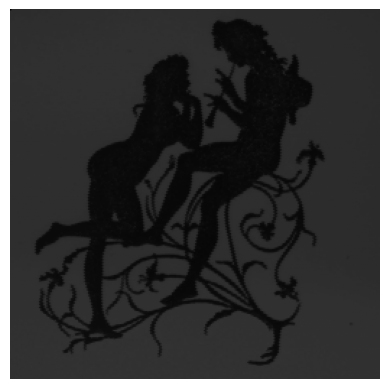

In [239]:
amour_imagen = cv2.imread('images/AMOUR.png', cv2.IMREAD_GRAYSCALE)

plt.imshow(amour_imagen, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 3.3 Realice la operación de apertura usando una máscara cuadrada de tamaño 5x5. ¿Qué partes fueron suprimidas? 

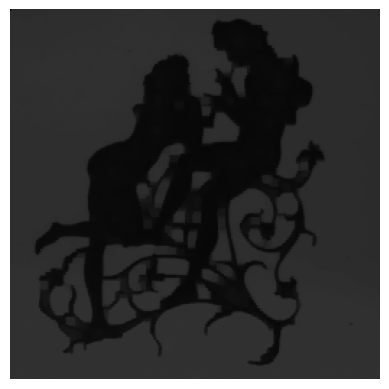

In [240]:
from skimage.morphology import opening

amour_apertura = opening(amour_imagen, footprint=footprint_rectangle((5, 5)))

plt.imshow(amour_apertura, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

Al aplicar la apertura con una máscara cuadrada de 5x5, se suprimieron las terminaciones finas y pequeños salientes de los detalles delgados, mientras que las siluetas principales se conservaron.

### 3.4 Retome la imagen original, y aplique una umbralización para binarizarla (umbral = 35).

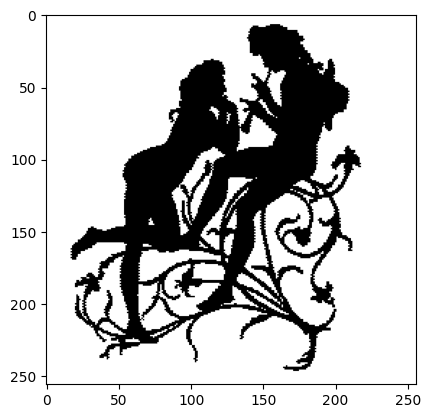

In [241]:
thres_value, amour_umbralizacion = cv2.threshold(amour_imagen, 35, 255, cv2.THRESH_BINARY)

plt.imshow(amour_umbralizacion, cmap='gray', vmin=0, vmax=255)
plt.show()

### 3.5 Realice el cierre de la imagen. Para esto, efectúe 4 cierres aplicando sucesivamente las 4 máscaras lineales simétricas de tamaño 1x3 (en este orden: las dos diagonales ( / y después \ ), horizontal ( - ) y vertical ( | )). Las máscaras diagonales (u oblicuas) deben crearse generando una matriz de 3x3 y colocando 1’ s sobre las diagonales. Los demás elementos se deben dejar vacíos (SIN CEROS). La máscara horizontal debe crearse generando una matriz de 3x1 llena de 1’s. La máscara vertical debe crearse generando una matriz de 1x3 llena de 1’s.

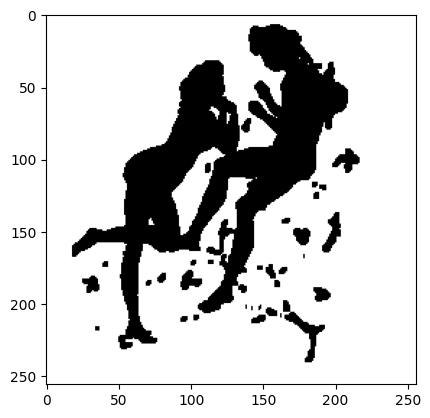

In [242]:
from skimage.morphology import closing

diagonal_1 = np.eye(3, dtype=np.uint8)
diagonal_2 = np.fliplr(np.eye(3, dtype=np.uint8))
horizontal = np.ones((1, 3), dtype=np.uint8)
vertical = np.ones((3, 1), dtype=np.uint8)

amour_cierre_diagonal_1 = closing(amour_umbralizacion, footprint=diagonal_1)
amour_cierre_diagonal_2 = closing(amour_cierre_diagonal_1, footprint=diagonal_2)
amour_cierre_horizontal = closing(amour_cierre_diagonal_2, footprint=horizontal)
amour_cierre_vertical = closing(amour_cierre_horizontal, footprint=vertical)

plt.imshow(amour_cierre_vertical, cmap='gray', vmin=0, vmax=255)
plt.show()

### 3.6 ¿Cuál es el efecto obtenido?

Se obtuvo el cierre de pequeños huecos y discontinuidades en la imagen binaria, haciendo que las siluetas principales quedaran más continuas y compactas. Además, varias regiones cercanas se conectaron mejor según la orientación de las máscaras aplicadas, aunque todavía permanecen algunos fragmentos pequeños aislados.

### 3.7 Tome el negativo de la imagen resultado, de forma tal que las figuras se vuelvan blancas.

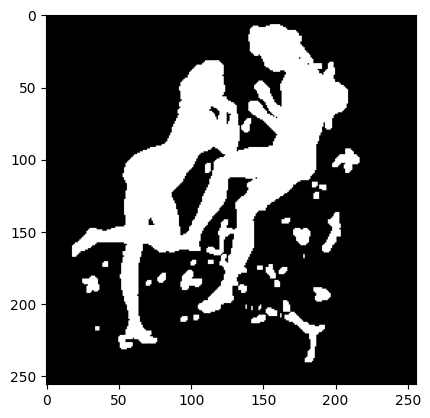

In [243]:
amour_negativo = cv2.bitwise_not(amour_cierre_vertical)

plt.imshow(amour_negativo, cmap='gray', vmin=0, vmax=255)
plt.show()

### 3.8 Seleccione el componente conexo más grande. ¿Cuál es el resultado?

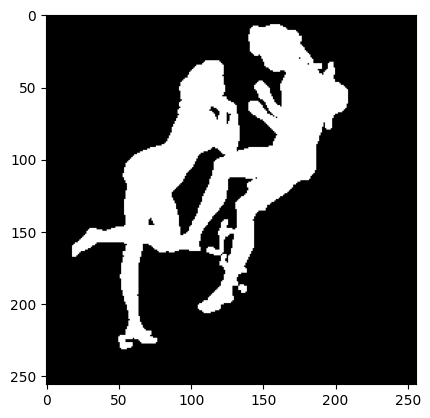

In [244]:
from skimage.measure import label, regionprops

componentes = label(amour_negativo, background=0, connectivity=2)
regiones = regionprops(componentes)
mayor_region = max(regiones, key=lambda x: x.area)
amour_componenten_conexo = np.zeros_like(componentes, dtype=np.uint8)
amour_componenten_conexo[componentes == mayor_region.label] = 255

plt.imshow(amour_componenten_conexo, cmap='gray')
plt.show()

Al seleccionar el componente conexo más grande, se conserva únicamente la figura principal de la imagen y se eliminan los fragmentos pequeños aislados. El negativo sirve para convertir las figuras en regiones blancas sobre fondo negro, lo que facilita la detección y el etiquetado de los componentes conectados, permitiendo aislar con mayor facilidad la estructura dominante.

## 4. Etiquetado de objetos

### 4.2 Cargue y visualice la imagen sic.png.

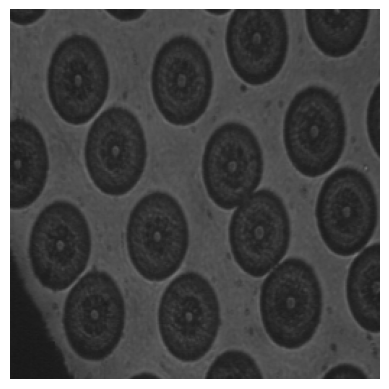

In [245]:
sic_img = cv2.imread('images/SIC.png', cv2.IMREAD_GRAYSCALE)

plt.imshow(sic_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 4.3 Umbralice esta imagen de forma tal que las células del fondo sean separadas (umbral entre 55 y 70), y calcule su negativo.

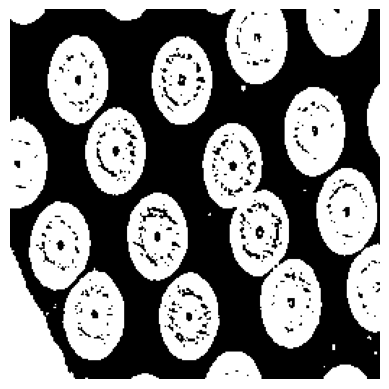

In [246]:
sic_thresh = np.where(sic_img < 55, 1, 0) # esto es lo mismo que umbralizar y calcular el negativo, las celulas quedan con clase 1
plt.imshow(sic_thresh, cmap='gray')
plt.axis('off')
plt.show()

### 4.4 Con una máscara en cruz de 3x3, haga dilataciones para rellenar los huecos al interior de las células. 

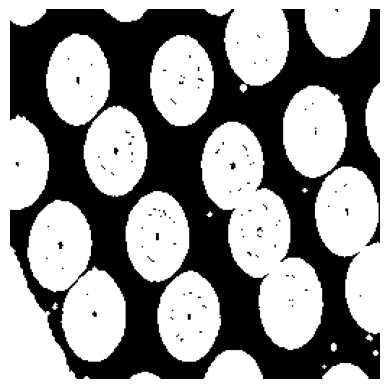

In [247]:
area = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
])

sic_dilated = dilation(sic_thresh, area)

plt.imshow(sic_dilated, cmap='gray')
plt.axis('off')
plt.show()

### 4.5 Cambie de máscaras: se utilizarán ahora máscaras lineales (oblicuas). Utilice las mismas máscaras oblicuas creadas en el punto de apertura y cierre de este taller. Con el operador de erosión, separe las diferentes células. Ayuda: Para separar las células es necesario erosionar por lo menos 10 veces con una máscara lineal oblicua (/) y 6 veces con una máscara ortogonal a la primera (\\).

In [248]:
diagonal_1 = np.eye(3, dtype=np.uint8)
diagonal_2 = np.fliplr(np.eye(3, dtype=np.uint8))
print(diagonal_1)
print(diagonal_2)

[[1 0 0]
 [0 1 0]
 [0 0 1]]
[[0 0 1]
 [0 1 0]
 [1 0 0]]


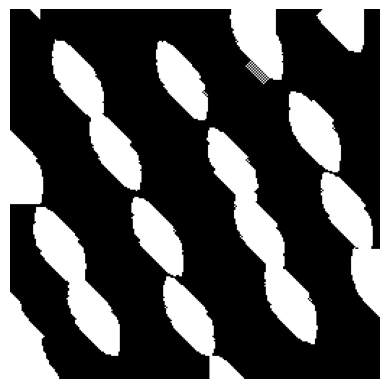

In [249]:
separated_cells_img = sic_dilated
for i in range(10):
    separated_cells_img = erosion(separated_cells_img, diagonal_2)
    
for i in range(6):
    separated_cells_img = dilation(separated_cells_img, diagonal_1)
    
plt.imshow(separated_cells_img, cmap='gray')
plt.axis('off')
plt.show()

### 3.6 Etiquete la imagen y visualice el resultado. Determine cuántas células enteras fueron detectadas ¿Qué ocurre con el borde?

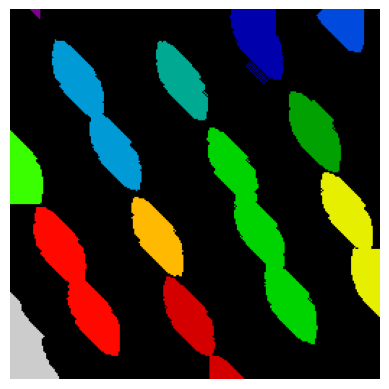

Number of connected components: 13


In [250]:
from skimage.measure import label

connected_components = label(separated_cells_img, background=0, connectivity=2)

plt.imshow(connected_components, cmap='nipy_spectral')
plt.axis('off')
plt.show()

print(f"Number of connected components: {connected_components.max()}")

El borde de las celulas se une a otras células en dirección vertical, mientas que se separan en dirección horizontal. Estos causa que se formen estructuras que involucran a más de una células, pero como están unidas, se detectan como un solo componente conexo.

También, la esquina inferior izquierda se detecta como otro componente conexo, aún así hayan células en esa áreas, esto sucede porque al binarizar y umbralizar la imagen, esta zona quedó con clase 1 al igual que las demás células.

## 5. Imagen de distancia

### 5.2 Cargue y visualice objects.png.

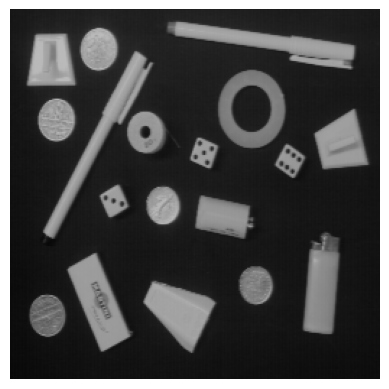

In [251]:
objects = cv2.imread('images/OBJECTS.png', cv2.IMREAD_GRAYSCALE)

plt.imshow(objects, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()

### 5.3 Umbralice esta imagen para separar los objetos del fondo (umbral=70).

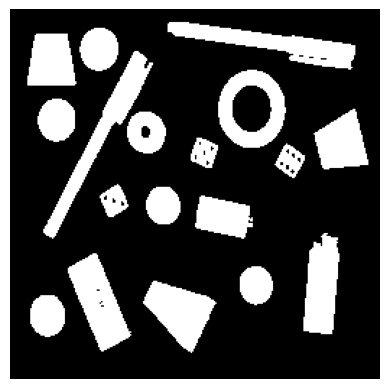

In [252]:
thres_value, objects_binary = cv2.threshold(objects, 70, 1, cv2.THRESH_BINARY)

plt.imshow(objects_binary, cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.show()

### 5.4 Calcule la imagen de distancia. Puede efectuar una expansión del contraste sobre la imagen de distancia para visualizar mejor el resultado. Ajuste el Window/Level.

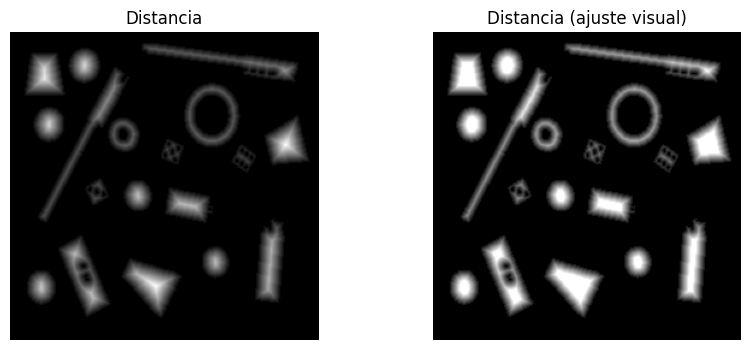

In [253]:
from scipy.ndimage import distance_transform_edt
from skimage import exposure

objects_distances = distance_transform_edt(objects_binary)

p2, p98 = np.percentile(objects_distances, (2, 98))
objects_distances_wl = exposure.rescale_intensity(objects_distances, in_range=(p2, p98))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(objects_distances, cmap='gray')
plt.title('Distancia')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(objects_distances_wl, cmap='gray')
plt.title('Distancia (ajuste visual)')
plt.axis('off')
plt.show()


### 5.5 Calcule ahora el negativo de la imagen umbralizada del punto 3. Ahora realice el cálculo de la distancia euclidiana. Utilizando la imagen resultante, determine la distancia mínima entre los dos lápices. Utilice máscaras y operaciones sobre pixeles para determinar el valor del pixel en el mapa de distancias a medio camino entre la distancia mínima de los dos lápices.

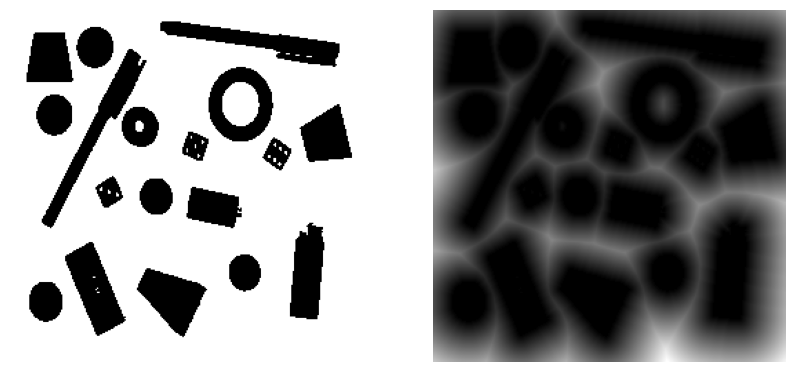

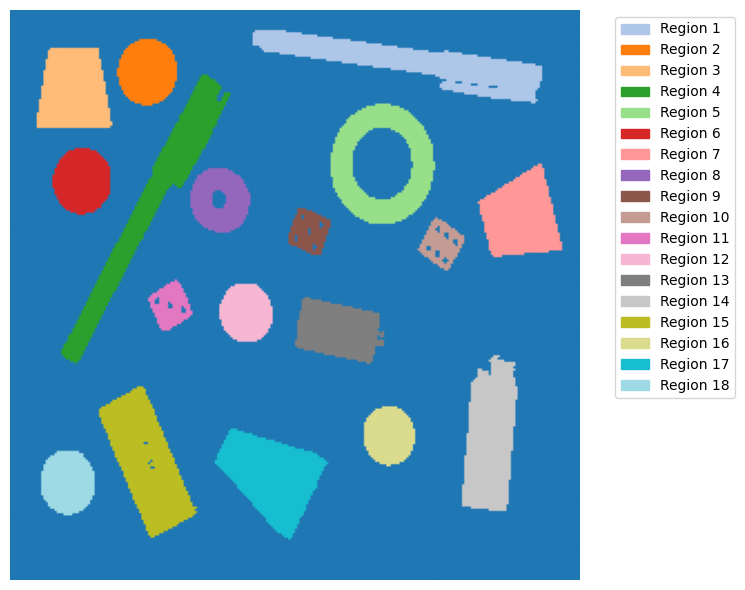

In [254]:
import matplotlib.patches as mpatches

thresh_neg = (objects_binary == 0).astype(np.uint8) # negativo
dist_edt = distance_transform_edt(thresh_neg)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.axis('off')
plt.imshow(thresh_neg, cmap='gray')
plt.subplot(1, 2, 2)
plt.axis('off')
plt.imshow(dist_edt, cmap='gray')

labels = label(objects_binary, background=0, connectivity=2)

fig, ax = plt.subplots(figsize=(8, 6))

cmap = plt.get_cmap('tab20')
im = ax.imshow(labels, cmap=cmap)

unique_labels = np.unique(labels)
unique_labels = unique_labels[unique_labels != 0]

legend_patches = []
max_label = labels.max()

for lbl in unique_labels:
    color = cmap(lbl / max_label)
    patch = mpatches.Patch(color=color, label=f'Region {lbl}')
    legend_patches.append(patch)

ax.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.axis('off')

plt.tight_layout()
plt.show()

Los lápices son la región 1 y la región 4.

**Algoritmo**: se calculan la distancia euclidiana entre los puntos, y se selecciona el par de puntos con la distancia más corta entre ellos. Se encuentra la coordenada del punto medio entre ellos y se visualiza el punto que se encuentra en esa posición.

Distancia mínima entre los lápices: 24.04
Coordenadas del punto más cercano en Región 1: [ 15 109]
Coordenadas del punto más cercano en Región 4: [32 92]
Coordenadas del punto medio: (24, 100)
Valor en dist_neg en el punto medio: 11.31


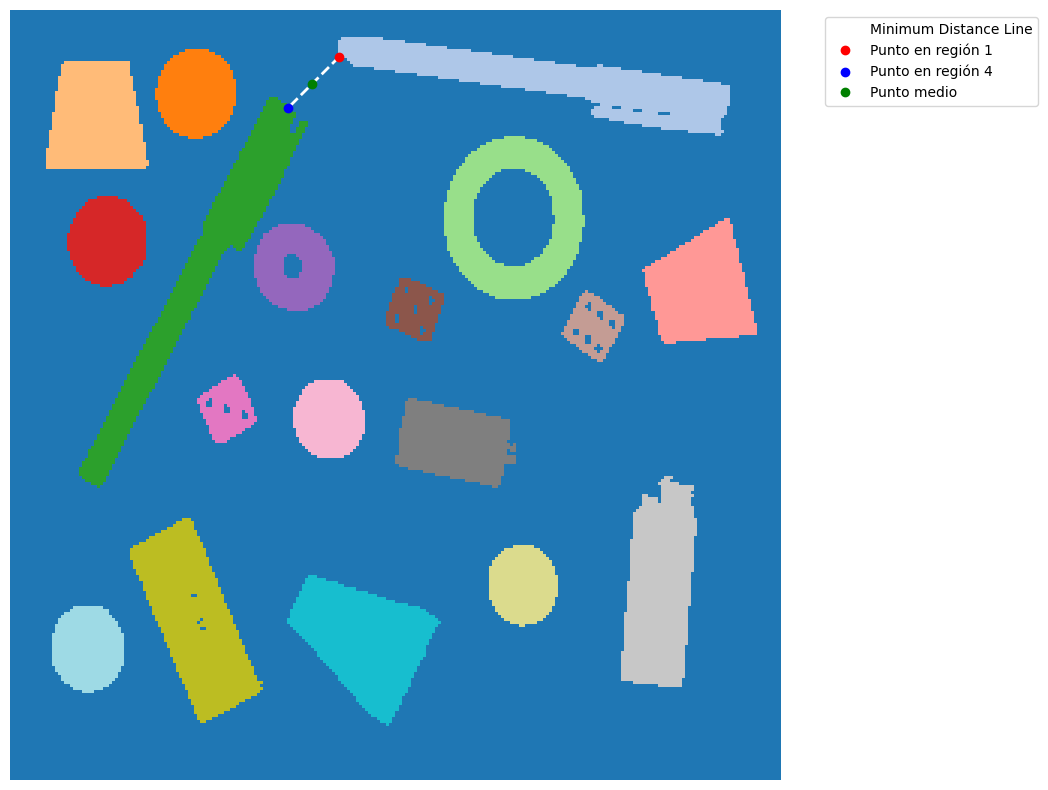

In [255]:
# crear máscaras y obtener coordenadas de los píxeles que pertenecen a las regiones 1 y 4
mask_r1 = (labels == 1)
mask_r4 = (labels == 4)

coords_r1 = np.argwhere(mask_r1)
coords_r4 = np.argwhere(mask_r4)

min_distance = np.inf
pixel_r1_min = None
pixel_r4_min = None

for p1 in coords_r1:
    # Calcular distancia euclidiana desde p1 a todos los píxeles en coords_r4
    distancias = np.sqrt(np.sum((coords_r4 - p1)**2, axis=1))
    
    # encontrar la distancia mínima para este píxel
    current_min_distance = np.min(distancias)
    
    if current_min_distance < min_distance:
        min_distance = current_min_distance
        pixel_r1_min = p1
        
        idx_r4_min = np.argmin(distancias)
        pixel_r4_min = coords_r4[idx_r4_min]

mid_point = (pixel_r1_min + pixel_r4_min) / 2.0

# convertir a enteros para que sean indices validos
fila_medio = int(np.round(mid_point[0]))
col_medio = int(np.round(mid_point[1]))

# valor del mapa de distancias del punto medio
valor_dist_neg = dist_edt[fila_medio, col_medio]

print(f"Distancia mínima entre los lápices: {min_distance:.2f}")
print(f"Coordenadas del punto más cercano en Región 1: {pixel_r1_min}")
print(f"Coordenadas del punto más cercano en Región 4: {pixel_r4_min}")
print(f"Coordenadas del punto medio: ({fila_medio}, {col_medio})")
print(f"Valor en dist_neg en el punto medio: {valor_dist_neg:.2f}")

fig, ax = plt.subplots(figsize=(10, 8))

cmap = plt.get_cmap('tab20')
ax.imshow(labels, cmap=cmap)

y1, x1 = pixel_r1_min
y2, x2 = pixel_r4_min
ym, xm = fila_medio, col_medio

# línea entre los puntos más cercanos
ax.plot([x1, x2], [y1, y2], color='white', linestyle='--', linewidth=2, label='Minimum Distance Line')

ax.plot(x1, y1, 'ro', markersize=6, label='Punto en región 1')
ax.plot(x2, y2, 'bo', markersize=6, label='Punto en región 4')
ax.plot(xm, ym, 'go', markersize=6, label='Punto medio')

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.axis('off')

plt.tight_layout()
plt.show()

## 6. Esqueleto y adelgazamiento de una imagen

### 6.2 Cargue y visualice la imagen rect.png.


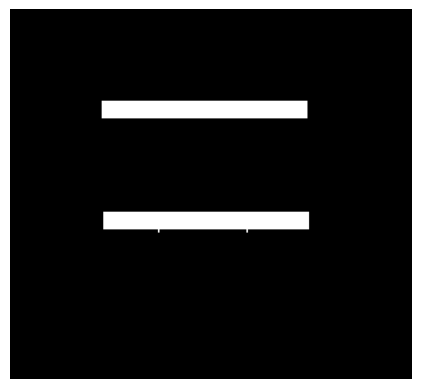

In [256]:
rect_img = cv2.imread('images/RECT.png', cv2.IMREAD_GRAYSCALE)

plt.imshow(rect_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()


### 6.3 Efectúe la esqueletización de esta imagen. Pruebe method='zhang' y method='lee'. Compare resultados. Explique cómo funcionan ambos algoritmos en términos generales.


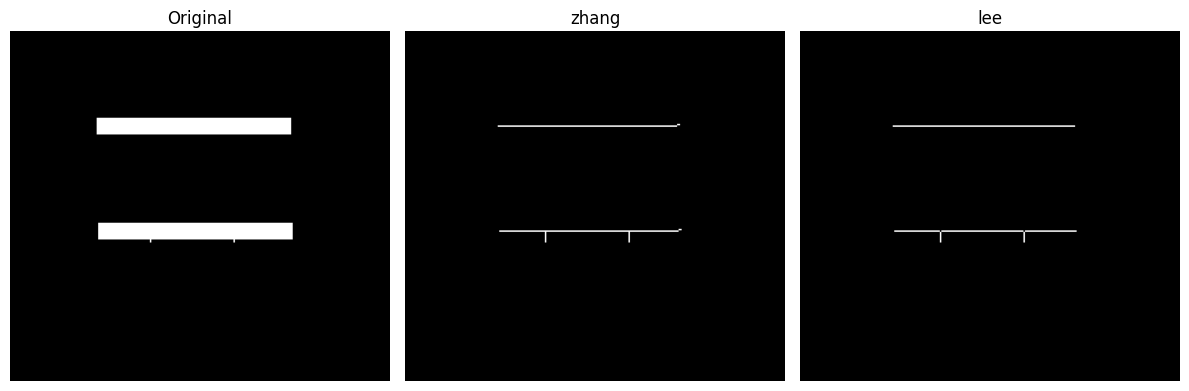

In [257]:
from skimage.morphology import skeletonize

skel_zhang = skeletonize(rect_img, method='zhang')
skel_lee = skeletonize(rect_img, method='lee')

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(rect_img, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(skel_zhang, cmap='gray')
axes[1].set_title('zhang')
axes[1].axis('off')

axes[2].imshow(skel_lee, cmap='gray')
axes[2].set_title('lee')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Los métodos zhang y lee producen resultados visualmente similares. Ambos reducen los rectángulos gruesos a líneas de un píxel de ancho situadas en el centro geométrico. En el rectángulo inferior de la imagen original, existen dos pequeñas protuberancias hacia abajo. Ambos algoritmos interpretan estas protuberancias como características topológicas de la forma, no como ruido. Por lo tanto, conservan estas características creando pequeñas ramificaciones hacia abajo en la línea central inferior.

Zhang parece conservar la línea horizontal central mejor que Lee, manteniéndola más continua. Cuando se presentan las protuberancias, lee tiende a generar una ramificación y desviación de la línea central, por lo que se observa que lee parece ser más sensible a las irregularidades de la forma.

El método de Zhang-Suen funciona retirando los píxeles del contorno exterior de la forma capa por capa hasta que queda una línea de un píxel de grosor. Opera en iteraciones de dos pasos. El primer paso elimina los píxeles de los bordes sur y este, y las esquinas noroeste. El segundo paso elimina los bordes norte y oeste, y las esquinas sureste. Después, evalúa una ventana de 3x3 alrededor de cada píxel para determinar si eliminarlo rompería la conectividad de la línea. Si la conectividad se mantiene y no es un punto final (extremo de una línea), el píxel se elimina. El proceso se repite hasta que ninguna pasada produce cambios, momento en el que el objeto ha quedado reducido a su esqueleto de un píxel de grosor.

Lee sigue la misma estructura general de iteraciones con dos subpasadas y eliminación simultánea, pero refina las condiciones de eliminación para ser más estricto con la preservación topológica. Antes de marcar un píxel como eliminable, verifica con mayor detalle que el píxel sea un punto de borde simple y que su vecindad no presente ninguna configuración que pudiera romper la conectividad del objeto al eliminarlo. Esto hace que el algoritmo sea más conservador en cada decisión, descartando menos píxeles por iteración que Zhang-Suen, pero garantizando que el esqueleto resultante sea topológicamente correcto incluso en formas con curvas pronunciadas, bifurcaciones o cruces complejas.

### 6.4 Efectúe un adelgazamiento de la imagen original. Puede efectuar una calibración del histograma de la imagen obtenida para visualizar mejor el resultado. Compare el resultado con los de la esqueletización.


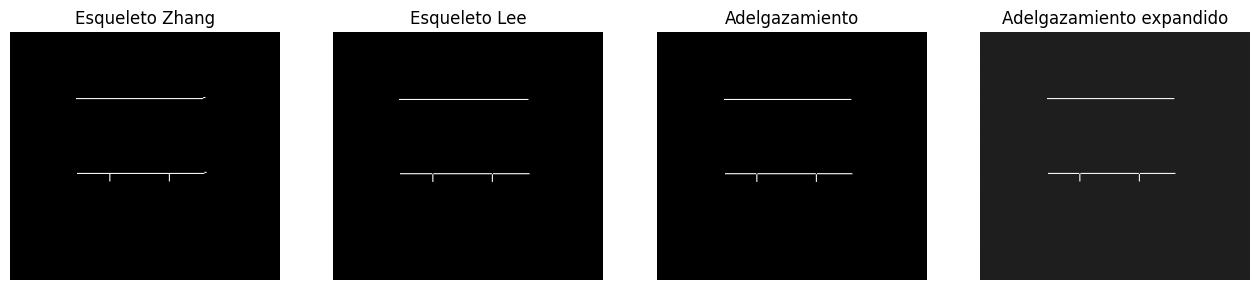

In [258]:
from skimage.morphology import thin
from skimage import exposure

rect_thin = thin(rect_img)
rect_thin_expanded = exposure.rescale_intensity(rect_thin, in_range=(0, 1), out_range=(30, 255))

plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1)
plt.imshow(rect_skel_zhang, cmap='gray')
plt.title('Esqueleto Zhang')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(rect_skel_lee, cmap='gray')
plt.title('Esqueleto Lee')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(rect_thin, cmap='gray')
plt.title('Adelgazamiento')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(rect_thin_expanded, cmap='gray', vmin=0, vmax=255)
plt.title('Adelgazamiento expandido')
plt.axis('off')
plt.show()


El resultado de adelgazamiento de la imagen es muy similar al de la esqueletización de Lee.

El adelgazamiento secuencial, al basarse en patrones de eliminación iterativa, tiende a ser más ruidoso y a preservar más detalles de contorno en forma de ramificaciones, y por eso, en este caso de una forma simple, el nivel de detalle es simlar al de la esqueletización de Lee. 

Ambos métodos de esqueletización y el de adelgazamiento identifican las pequeñas protuberancias como características topológicas que se deben preservar.


### 6.5 Cargue y visualice la imagen angio.png.


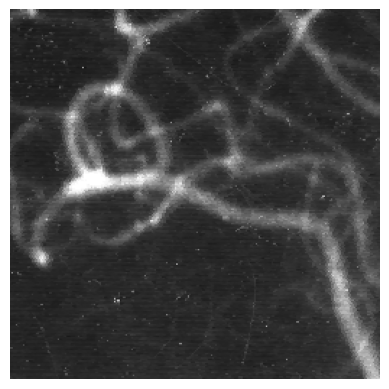

In [259]:
angio_imagen = cv2.imread('images/ANGIO.png', cv2.IMREAD_GRAYSCALE)

plt.imshow(angio_imagen, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.show()


### 6.6 Umbralice con OTSU y filtre con cierre + apertura usando máscara en cruz 3x3.


Umbral OTSU utilizado: 88.00


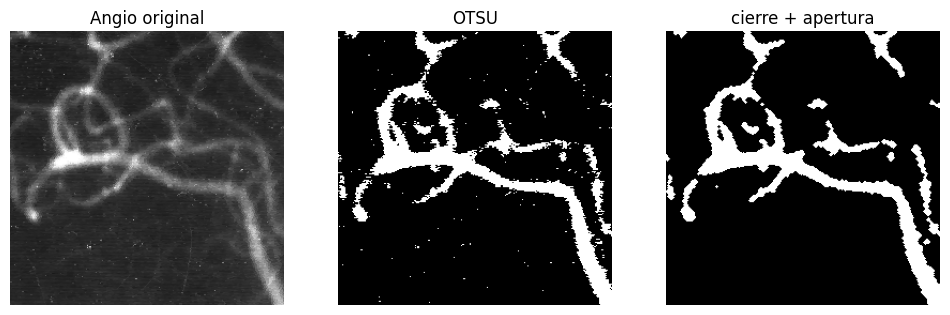

In [260]:
thres_value, angio_otsu = cv2.threshold(angio_imagen, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

mascara_cruz = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
], dtype=np.uint8)

angio_cierre = closing(angio_otsu, footprint=mascara_cruz)
angio_filtrada = opening(angio_cierre, footprint=mascara_cruz)

print(f'Umbral OTSU utilizado: {thres_value:.2f}')

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(angio_imagen, cmap='gray', vmin=0, vmax=255)
plt.title('Angio original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(angio_otsu, cmap='gray')
plt.title('OTSU')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(angio_filtrada, cmap='gray')
plt.title('cierre + apertura')
plt.axis('off')
plt.show()


### 6.7 Efectúe esqueletización y adelgazamiento de la imagen filtrada. Compare los resultados de estos dos tratamientos.


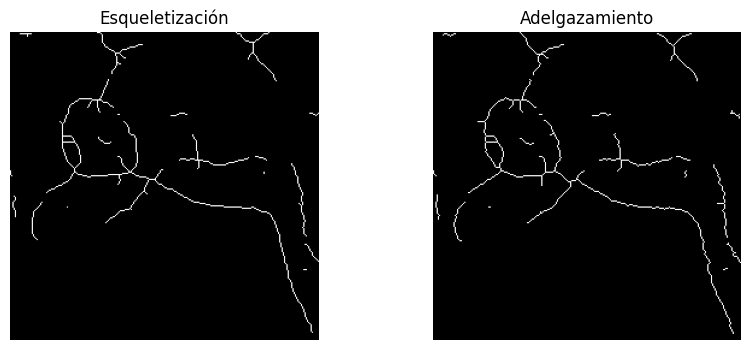

In [261]:
angio_skeleton = skeletonize(angio_filtrada.astype(bool), method='zhang')
angio_thin = thin(angio_filtrada.astype(bool))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(angio_skeleton, cmap='gray')
plt.title('Esqueletización')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(angio_thin, cmap='gray')
plt.title('Adelgazamiento')
plt.axis('off')
plt.show()


Ambos resultados conservan la red vascular principal, y aunque los resultados no son copias exactas, sí conservan la estructura general de la imagen original y los detalles más importantes. Las ramificaciones son identificadas aunque varía que tan rectas son las línas y de donde parten de manera mínima. El adelgazamiento parece generar líneas con un mayor número de curvas y diagonales entre píxeles, mientras que las líneas de la esqueletización son más rectas.


### 6.8 Sobreponga la imagen adelgazada a la imagen angio.png (calculando el máximo entre las dos imágenes) para observar la localización de las líneas con respecto a la imagen inicial. Describa de forma cualitativa el resultado obtenido.


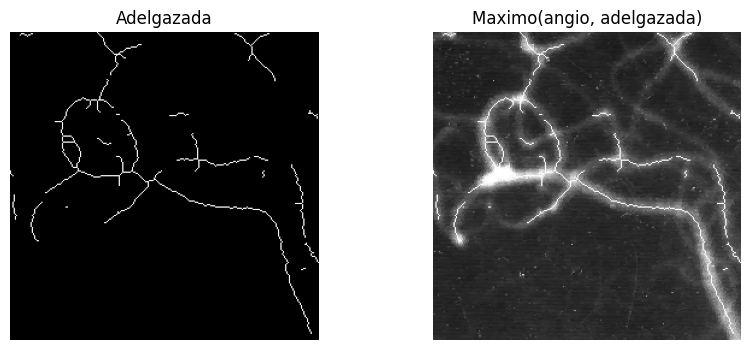

In [262]:
angio_thin_255 = (angio_thin.astype(np.uint8) * 255)
angio_superpuesta = np.maximum(angio_imagen, angio_thin_255)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(angio_thin_255, cmap='gray', vmin=0, vmax=255)
plt.title('Adelgazada')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(angio_superpuesta, cmap='gray', vmin=0, vmax=255)
plt.title('Maximo(angio, adelgazada)')
plt.axis('off')
plt.show()


Cualitativamente, las lineas adelgazadas quedan alineadas con vasos de mayor contraste en la imagen original. En zonas con bajo contraste aparecen interrupciones. No se observan lineas adicionales de ramificaciones falsas, lo que más sucede es que el esqueleto no logra capturar las ramificaciones originales con toda su continuidad al fragmentarse debido a las estructuras resultantes con la umbralización.


## 7. Ejercicio de síntesis taller 6

### Ejercicio 1 elegido (objects.png)


Se carga la imagen y se umbraliza para obtener una imagen binaria con los objetos de interés.


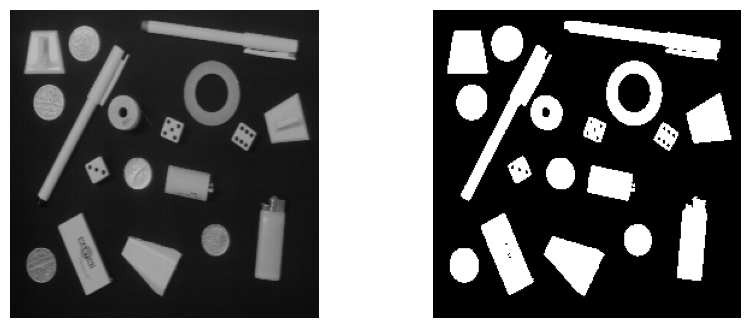

In [263]:
objects_img = cv2.imread('images/OBJECTS.png', cv2.IMREAD_GRAYSCALE)
thres_value, objects_binary = cv2.threshold(objects_img, 70, 1, cv2.THRESH_BINARY)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(objects_img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(objects_binary, cmap='gray')
plt.axis('off')
plt.show()


Se hace una operación de erosión con un elemento estructurante de tamaño 15x15, lo cual eliminará los objetos con grosor menor a 15 píxeles, y sobreviven los objetos con espesor de por lo menos 15 píxeles. Los objetos sobrevivientes se podrán usar para extraer las semillas.

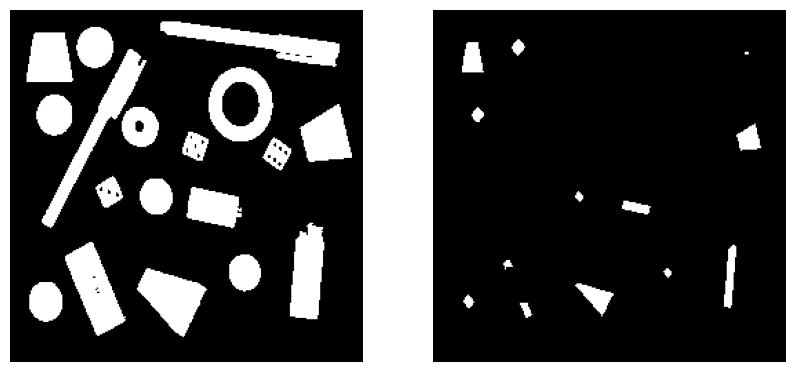

In [ ]:
from skimage.morphology import erosion

element = footprint_rectangle((14, 14))
survivors = erosion(objects_binary, element)

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
plt.imshow(objects_binary, cmap='gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(survivors, cmap='gray')
plt.axis('off')
plt.show()

Se extraen los componentes conexos de los objetos sobrevivientes y se escoje un píxel por cada componente.

In [265]:
cc = label(survivors, background=0, connectivity=2)

seeds = []

seeded_survivors = []

for i in range(1, cc.shape[0]):
    for j in range(1, cc.shape[1]):
        if cc[i, j] != 0 and cc[i, j] not in seeded_survivors:
            seeds.append((i, j))
            seeded_survivors.append(cc[i, j])

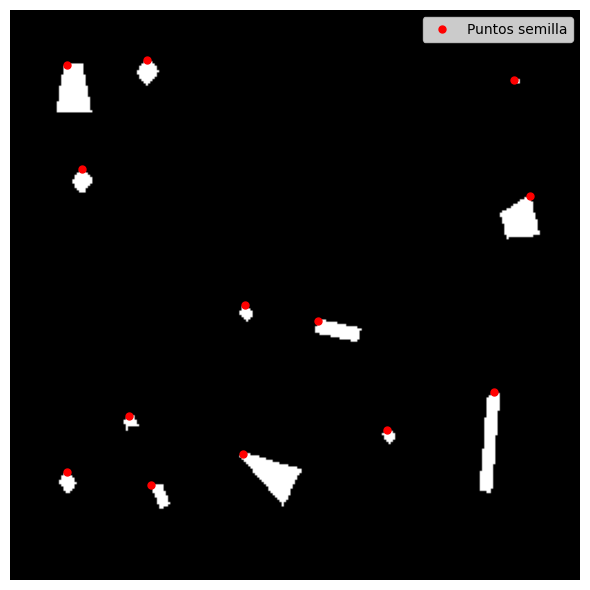

In [266]:
y_coords = [seed[0] for seed in seeds]
x_coords = [seed[1] for seed in seeds]

fig, ax = plt.subplots(figsize=(6, 6))

ax.imshow(survivors, cmap='gray')

ax.plot(x_coords, y_coords, 'ro', markersize=5, label='Puntos semilla')

ax.legend(loc='upper right')
ax.axis('off')
plt.tight_layout()
plt.show()

Se realiza crecimiento de regiones, sobre la imagen binaria, con las semillas extraídas de los objetos sobrevivientes a la erosión.

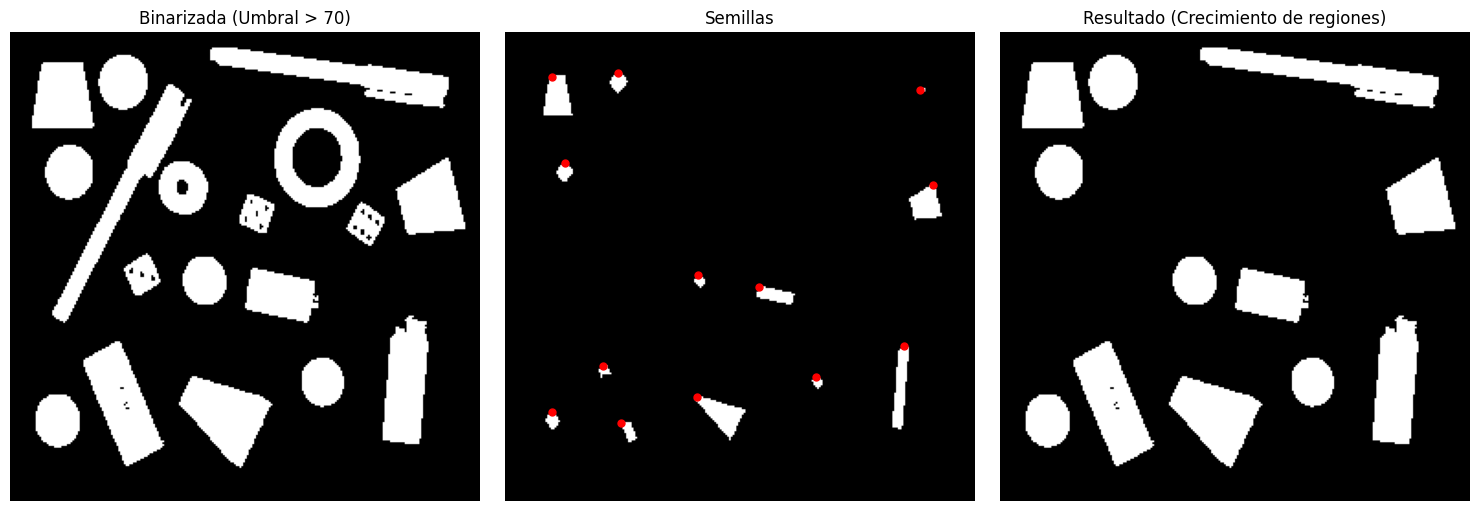

In [ ]:
result = np.zeros_like(objects_binary, dtype=bool)

for seed in seeds:
    # tolerancia 0 hace que solo se crezcan regiones con píxeles de valor True
    obj_mask = flood(objects_binary, seed, tolerance=0)
    
    # se unen las regiones encontradas
    result = result | obj_mask

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(objects_binary, cmap='gray')
axes[0].set_title('Binarizada (Umbral > 70)')
axes[0].axis('off')

axes[1].imshow(survivors, cmap='gray')
axes[1].plot(x_coords, y_coords, 'ro', markersize=5, label='Puntos semilla')
axes[1].set_title('Semillas')
axes[1].axis('off')

axes[2].imshow(result, cmap='gray')
axes[2].set_title('Resultado')
axes[2].axis('off')

plt.tight_layout()
plt.show()